In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('Product_Reviews.csv') 

In [4]:
data.head()

,product_id,product_title,rating,summary,review,location,date,upvotes,downvotes
0,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,1-more flexible2-bass is very high3-sound clar...,Shirala,8 months ago,1390,276
1,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Super sound and good looking I like that prize,Visakhapatnam,8 months ago,643,133
2,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,Very much satisfied with the device at this pr...,Kozhikode,"Feb, 2020",1449,328
3,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,"Nice headphone, bass was very good and sound i...",Jaora,7 months ago,160,28
4,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Sound quality super battery backup super quali...,New Delhi,8 months ago,533,114


In [5]:
data['combined'] = data['review'] + " " + data['summary']

In [6]:
data.head()

,product_id,product_title,rating,summary,review,location,date,upvotes,downvotes,combined
0,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,1-more flexible2-bass is very high3-sound clar...,Shirala,8 months ago,1390,276,1-more flexible2-bass is very high3-sound clar...
1,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Super sound and good looking I like that prize,Visakhapatnam,8 months ago,643,133,Super sound and good looking I like that prize...
2,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,Very much satisfied with the device at this pr...,Kozhikode,"Feb, 2020",1449,328,Very much satisfied with the device at this pr...
3,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,"Nice headphone, bass was very good and sound i...",Jaora,7 months ago,160,28,"Nice headphone, bass was very good and sound i..."
4,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Sound quality super battery backup super quali...,New Delhi,8 months ago,533,114,Sound quality super battery backup super quali...


In [7]:
data.shape

(9374, 10)

In [8]:
data.isnull().sum()

product_id          0
product_title       0
rating              0
summary             0
review              0
location         1293
date                0
upvotes             0
downvotes           0
combined            0
dtype: int64

In [9]:
data['location'] = data['location'].fillna('')

In [10]:
data.isnull().sum()

product_id       0
product_title    0
rating           0
summary          0
review           0
location         0
date             0
upvotes          0
downvotes        0
combined         0
dtype: int64

In [11]:
data['rating'].value_counts()

rating
5    5395
4    1959
1    1090
3     622
2     308
Name: count, dtype: int64

In [12]:
import re

In [13]:
data['combined'][0]

"1-more flexible2-bass is very high3-sound clarity is good 4-battery back up to 6 to 8 hour's 5-main thing is fastest charging system is available in that. Only 20 min charge and get long up to 4 hours back up 6-killing look awesome 7-for gaming that product does not support 100% if you want for gaming then I'll recommend you please don't buy but you want for only music then this product is very well for you.. 8-no more wireless headphones are comparing with that headphones at this pric... Terrific purchase"

In [14]:
review = re.sub('[^a-zA-Z]',' ',data['combined'][0])
review

'  more flexible  bass is very high  sound clarity is good   battery back up to   to   hour s   main thing is fastest charging system is available in that  Only    min charge and get long up to   hours back up   killing look awesome   for gaming that product does not support      if you want for gaming then I ll recommend you please don t buy but you want for only music then this product is very well for you     no more wireless headphones are comparing with that headphones at this pric    Terrific purchase'

In [15]:
review = review.lower()

In [16]:
review

'  more flexible  bass is very high  sound clarity is good   battery back up to   to   hour s   main thing is fastest charging system is available in that  only    min charge and get long up to   hours back up   killing look awesome   for gaming that product does not support      if you want for gaming then i ll recommend you please don t buy but you want for only music then this product is very well for you     no more wireless headphones are comparing with that headphones at this pric    terrific purchase'

In [17]:
review = review.split()

In [18]:
review

['more',
 'flexible',
 'bass',
 'is',
 'very',
 'high',
 'sound',
 'clarity',
 'is',
 'good',
 'battery',
 'back',
 'up',
 'to',
 'to',
 'hour',
 's',
 'main',
 'thing',
 'is',
 'fastest',
 'charging',
 'system',
 'is',
 'available',
 'in',
 'that',
 'only',
 'min',
 'charge',
 'and',
 'get',
 'long',
 'up',
 'to',
 'hours',
 'back',
 'up',
 'killing',
 'look',
 'awesome',
 'for',
 'gaming',
 'that',
 'product',
 'does',
 'not',
 'support',
 'if',
 'you',
 'want',
 'for',
 'gaming',
 'then',
 'i',
 'll',
 'recommend',
 'you',
 'please',
 'don',
 't',
 'buy',
 'but',
 'you',
 'want',
 'for',
 'only',
 'music',
 'then',
 'this',
 'product',
 'is',
 'very',
 'well',
 'for',
 'you',
 'no',
 'more',
 'wireless',
 'headphones',
 'are',
 'comparing',
 'with',
 'that',
 'headphones',
 'at',
 'this',
 'pric',
 'terrific',
 'purchase']

In [19]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to C:\Users\MY
[nltk_data]     LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
all_stopwords = stopwords.words("english")
all_stopwords.remove('not')

In [21]:
all_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'o

In [22]:
review = [word for word in review if word not in set(all_stopwords)]

In [23]:
review

['flexible',
 'bass',
 'high',
 'sound',
 'clarity',
 'good',
 'battery',
 'back',
 'hour',
 'main',
 'thing',
 'fastest',
 'charging',
 'system',
 'available',
 'min',
 'charge',
 'get',
 'long',
 'hours',
 'back',
 'killing',
 'look',
 'awesome',
 'gaming',
 'product',
 'not',
 'support',
 'want',
 'gaming',
 'recommend',
 'please',
 'buy',
 'want',
 'music',
 'product',
 'well',
 'wireless',
 'headphones',
 'comparing',
 'headphones',
 'pric',
 'terrific',
 'purchase']

In [24]:
from nltk.stem.porter import PorterStemmer

In [25]:
ps = PorterStemmer()

In [26]:
review = [ps.stem(word) for word in review]

In [27]:
review = " ".join(review)

In [28]:
review

'flexibl bass high sound clariti good batteri back hour main thing fastest charg system avail min charg get long hour back kill look awesom game product not support want game recommend pleas buy want music product well wireless headphon compar headphon pric terrif purchas'

In [29]:
import re
custom_stopwords = {'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't",
                    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't",
                    'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
                    'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't",
                    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}

corpus =[]
ps =PorterStemmer()
stop_words = set(stopwords.words("english")) - custom_stopwords

def clean_my_text(text):
    review = re.sub('[^a-zA-Z]', ' ', str(text)).lower().split()
    review = [ps.stem(word) for word in review if word not in stop_words]
    return " ".join(review)

data['processed_text'] = data['combined'].apply(clean_my_text)

In [30]:
data.head()

,product_id,product_title,rating,summary,review,location,date,upvotes,downvotes,combined,processed_text
0,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,1-more flexible2-bass is very high3-sound clar...,Shirala,8 months ago,1390,276,1-more flexible2-bass is very high3-sound clar...,flexibl bass high sound clariti good batteri b...
1,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Super sound and good looking I like that prize,Visakhapatnam,8 months ago,643,133,Super sound and good looking I like that prize...,super sound good look like prize terrif purchas
2,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,Very much satisfied with the device at this pr...,Kozhikode,"Feb, 2020",1449,328,Very much satisfied with the device at this pr...,much satisfi devic price point awesom brand de...
3,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,"Nice headphone, bass was very good and sound i...",Jaora,7 months ago,160,28,"Nice headphone, bass was very good and sound i...",nice headphon bass good sound clear purchas ca...
4,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Sound quality super battery backup super quali...,New Delhi,8 months ago,533,114,Sound quality super battery backup super quali...,sound qualiti super batteri backup super quali...


In [31]:
def map_sentiment(rating):
    if rating <= 2:
        return 0 
    elif rating == 3:
        return 1
    else:
        return 2

data['sentiment'] = data['rating'].apply(map_sentiment)

print("Sentiment counts before balancing:")
print(data['sentiment'].value_counts())

Sentiment counts before balancing:
sentiment
2    7354
0    1398
1     622
Name: count, dtype: int64


In [32]:
negative_reviews = data[data['sentiment'] == 0]
neutral_reviews = data[data['sentiment'] == 1]
positive_reviews = data[data['sentiment'] == 2]

min_count = min(len(negative_reviews), len(neutral_reviews), len(positive_reviews))

neg_balanced = negative_reviews.sample(n=min_count, random_state=42)
neu_balanced = neutral_reviews.sample(n=min_count, random_state=42)
pos_balanced = positive_reviews.sample(n=min_count, random_state=42)

balanced_data = pd.concat([neg_balanced, neu_balanced, pos_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_data['sentiment'].value_counts())

sentiment
2    622
1    622
0    622
Name: count, dtype: int64


In [33]:
from wordcloud import WordCloud

In [34]:
wc = WordCloud(width=500,height=500,min_font_size=8,background_color="white")

In [35]:
pos = wc.generate(data[data['rating']>=4]['processed_text'].str.cat(sep=" "))

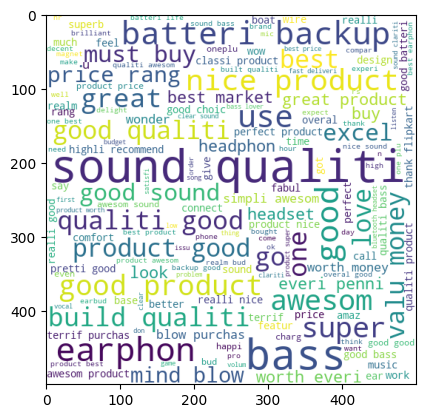

In [36]:
plt.imshow(pos)

In [37]:
neu = wc.generate(data[data['rating']==3]['processed_text'].str.cat(sep=" "))

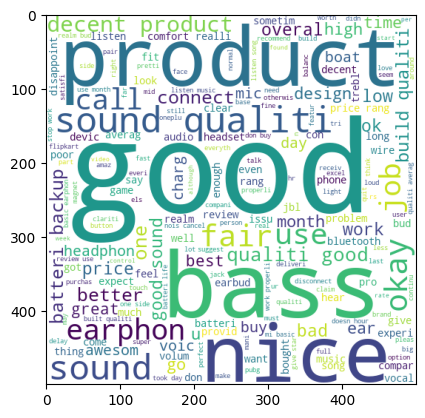

In [38]:
plt.imshow(neu)

In [39]:
neg = wc.generate(data[data['rating']<=2]['processed_text'].str.cat(sep=" "))

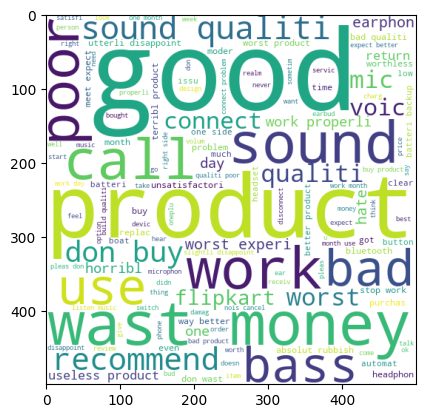

In [40]:
plt.imshow(neg)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

X = balanced_data['processed_text']
y = balanced_data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cv = CountVectorizer(max_features=1500)
X_train_vectorized = cv.fit_transform(X_train).toarray()
X_test_vectorized = cv.transform(X_test).toarray()

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vectorized, y_train)

y_pred = rf_model.predict(X_test_vectorized)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}") 
print("\nClassification Report:\n", classification_report(y_test, y_pred))

joblib.dump(cv, 'count_v_res')
joblib.dump(rf_model, 'Feedback_review_model')

Accuracy: 91.44%
Weighted F1-Score: 0.9148

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       137
           1       0.86      0.93      0.89       128
           2       0.92      0.88      0.90       109

    accuracy                           0.91       374
   macro avg       0.92      0.91      0.91       374
weighted avg       0.92      0.91      0.91       374



['Feedback_review_model']

In [ ]:
import re
import tkinter as tk
from tkinter import ttk, messagebox
import joblib
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

class FeedbackReviewAnalyser:
    def __init__(self, master):
        self.master = master
        master.title("E-Commerce Product Review Sentiment Analyzer")
        master.geometry("500x350")
        
        self.model = joblib.load("Feedback_review_model")
        self.vectorizer = joblib.load("count_v_res")
        
        self.label = ttk.Label(master, text="Enter your Product review:", font=("Helvetica", 14, "bold"))
        self.label.pack(pady=10)
        
        self.text_entry = tk.Text(master, height=5, width=40)
        self.text_entry.pack(pady=10)
        
        self.classify_button = ttk.Button(master, text="Classify", command=self.classify_review)
        self.classify_button.pack(pady=10)
        
        self.result_label = ttk.Label(master, text="", font=("Helvetica", 12, "bold"))
        self.result_label.pack(pady=10)
        
        self.style = ttk.Style()
        self.style.configure("Custom.TButton", font=("Helvetica", 12), width=15, foreground="black", background="#4CAF50", padding=(10, 5))
        self.classify_button.configure(style="Custom.TButton")

    def preprocess_text(self, text):
        review = text.lower()
        review = review.replace("didnt", "didn")
        review = review.replace("dont", "don")
        review = review.replace("wasnt", "wasn")
        review = review.replace("isnt", "isn")
        review = review.replace("couldnt", "couldn")
        
        review = re.sub("[^a-zA-Z]", " ", review)
        review = review.split()
        
        custom_stopwords = {'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", "didnt", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}
        stop_words = set(stopwords.words("english")) - custom_stopwords
            
        ps = PorterStemmer()
        review = [ps.stem(word) for word in review if word not in stop_words]
        return " ".join(review)

    def classify_review(self):
        user_input = self.text_entry.get("1.0", "end-1c").strip()
        
        if user_input:
            processed_text = self.preprocess_text(user_input)
            vectorized_text = self.vectorizer.transform([processed_text]).toarray()
            
            prediction = self.model.predict(vectorized_text)[0]
            
            if prediction == 2:
                sentiment = "Positive Review"
                text_color = "green"
            elif prediction == 1:
                sentiment = "Neutral Review"
                text_color = "#d4b800"
            else:
                sentiment = "Negative Review"
                text_color = "red"
                
            self.result_label.config(text=f"Predicted: {sentiment}", foreground=text_color)
        else:
            messagebox.showwarning("Input Error", "Please enter a review.")
if __name__ == "__main__":
    root = tk.Tk()
    app = FeedbackReviewAnalyser(root)
    root.mainloop()